<a href="https://colab.research.google.com/github/ShoSato-047/Act_2.3_intro_matplotlib_seaborn/blob/main/STAT380_6_2_Survival_analysis_2_Cox_PH_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Motivation

Kaplan-Meier survival/cumulative hazard curves are useful *exploratory* methods if we have one “exposure” variable that is discrete. If we:

* have continuous covariates;
* want to adjust the survival or hazard functions for other covariates;
* want to make inference (p-values/95% CI) on relationship between survival/hazard and covariates;
* want to make survival predictions;

we need sophistication beyond what Kaplan-Meier curves have to offer.  This motivates the Cox proportional hazards model.


# The Cox PH model

The *Cox proportional hazards (PH)* model is perhaps the most frequently used model in analysis of time-to-event data.  Given a set of covariates $\mathbf{X} = \{x_1,x_2,...,x_k\},$ the hazard rate $h(t,\mathbf{X})$ depends on both *time* and $\mathbf{X}$ as follows:

$$\ln(h(t,\mathbf{X})) = \ln(h_0(t)) + \beta_1 x_1 + ... + \beta_k x_k$$

* Here, $h_0(t)$ is a ***baseline hazard*** and is the only part of the model that depends on time.  
* The Cox PH model bears resemblance to Poisson/quasi-Poisson models, with a log-link and offset for the log baseline hazard.
* Model often expressed in its exponentiated form:

$$h(t,\mathbf{X}) = h_0(t)\exp(\beta_1 x_1 + ... + \beta_k x_k)$$

* Note: no $\beta_0$! $h_0(t)$ is the *hazard rate when all $x_i = 0$*.
* This Cox PH model is *semiparametric*:
  - Nonparametric: Form of baseline hazard $h_0(t)$ completely unspecified
  - Parametric: Relationship with covariates governed by relationship $\exp(\beta_1 x_1 + ... + \beta_k x_k)$


## Proportional hazards

* The "PH" aspect of the Cox PH model arises from the fact that at any time $t$,the hazard functions are *proportional* to each other.

* Consider covariate vector $\mathbf{X}_1$ and $\mathbf{X}_2$ and coefficient vector $\mathbf{\beta}$. e.g.
  - $\mathbf{X}_1$ = {50 year old, male, high blood pressure, on statins}
  - $\mathbf{X}_2$ = {45 year old, female, normal blood pressure, not on statins}

* Then:

$$\frac{h(t, \mathbf{X}_1)}{h(t, \mathbf{X}_2)} = \frac{h_0(t)\exp(\mathbf{X}_1\beta)}{h_0(t)\exp(\mathbf{X}_2\beta)} = \frac{\exp(\mathbf{X}_1\beta)}{\exp(\mathbf{X}_2\beta)}$$

Graphically, PH means *multiplicative* ratio is constant; ***not*** the same as parallel.  Both plots below have exactly proportional hazards:

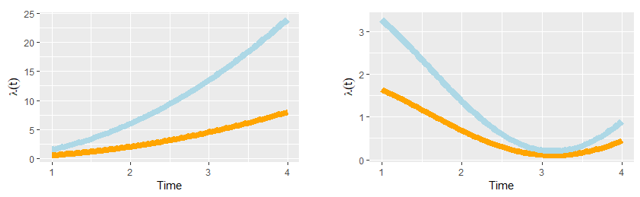

What this *does* imply is that the log-hazard functions are parallel:


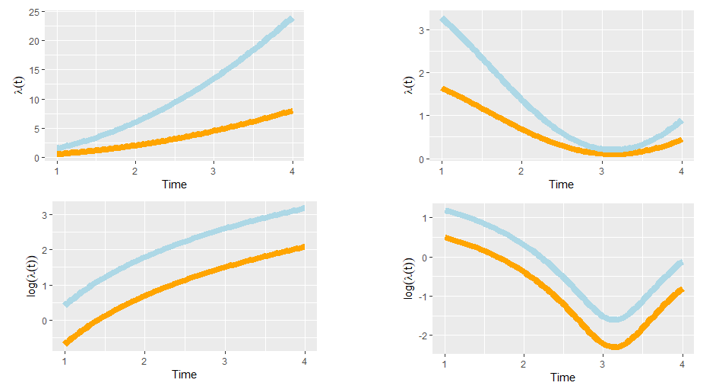

## Interpretation of coefficients

In general, $\exp⁡(\beta_𝑘)$ describes the multiplicative increase in the hazard rate at any time $𝑡$ for a 1-unit increase in $𝑥_𝑘$, *holding all other covariates constant*.


# Case study

Reconsider the leukemia data set:

* `Group`: indicates treatment status
* `logwbc`: indicates log white blood cell count
* `FUTime`: indicates total amount follow-up time (months)
* `Status`: 1 if death was observed; 0 if not (“Censored”)

We will fit the following:

$$h(t,x) = h_0(t) \exp(\beta_1 x)$$

* $x = 1$ for Group = 2, 0 for Group = 1


In [1]:
leukemia <- read.csv('https://www.dropbox.com/s/wu4pq1c729q8nu9/Leukemia2.csv?dl=1')
library(survival)
library(tidyverse)


Attaching package: ‘survival’


The following object is masked _by_ ‘.GlobalEnv’:

    leukemia


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
head(leukemia)

,Gender,Group,FUTime,Status,logwbc
,<int>,<int>,<int>,<int>,<dbl>
1,0,1,6,1,2.31
2,1,1,6,1,4.06
3,1,1,6,1,3.28
4,1,1,6,0,3.20
5,1,1,7,1,4.43
6,1,1,9,0,2.80


In [3]:
# Surv: combination of Y and censor status
coxfit <- coxph(Surv(FUTime, Status) ~ factor(Group), data = leukemia)
summary(coxfit)

Call:
coxph(formula = Surv(FUTime, Status) ~ factor(Group), data = leukemia)

  n= 42, number of events= 30 

                 coef exp(coef) se(coef)     z Pr(>|z|)    
factor(Group)2 1.5721    4.8169   0.4124 3.812 0.000138 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

               exp(coef) exp(-coef) lower .95 upper .95
factor(Group)2     4.817     0.2076     2.147     10.81

Concordance= 0.69  (se = 0.041 )
Likelihood ratio test= 16.35  on 1 df,   p=5e-05
Wald test            = 14.53  on 1 df,   p=1e-04
Score (logrank) test = 17.25  on 1 df,   p=3e-05


In [4]:
exp(1.5721)

[1] 4.816753

In [ ]:
# PH model gives interpretaion

**Interpretation:**

* $\exp(\hat\beta_1)=4.82$: the hazard rate at any time $𝑡$ is 4.8 times higher for subjects in Group 2 than subjects in Group 1.  

* We can be 95% confident that the true hazard at any time is between 2.1 and 10.8 times higher for subjects in Group 2 than subjects in Group 1

* Since the 95% CI does not overlap 1, and the p-value = 0.0001 < 0.05, there is significant evidence that the hazard of death is higher for Group 2 than Group 1 individuals.


## Estimating survival and cumulative hazard with the Cox PH model

To find the fitted survival and cumulative hazard curves from the Cox PH model, we use the `survfit()` function.  Note that now we feed in the Cox PH model, instead of just the raw data (which would yield the Kaplan-Meier estimates).  

Finding $\hat S_{Cox}(t,\mathbf{X})$ and $-\hat H_{Cox}(t,\mathbf{X})$ with `survfit()`:

In [5]:
cox.survfit <- survfit(coxfit, newdata = data.frame(Group = c(1,2)))
cox.survfit.data <- with(cox.survfit , data.frame(time, surv, cumhaz))
names(cox.survfit.data) <- c('time','S1','S2','H1','H2')
head(cox.survfit.data)


,time,S1,S2,H1,H2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.9834300,0.9226695,0.01670879,0.08048414
2,2,0.9657205,0.8453400,0.03488078,0.16801632
3,3,0.9563798,0.8066757,0.04460020,0.21483352
4,4,0.9365798,0.7293482,0.06552050,0.31560398
5,5,0.9150404,0.6520227,0.08878703,0.42767595
6,6,0.8804251,0.5414898,0.12735046,0.61343111


Of note:

In [6]:
# H2/H1 is eponentiated B1
with(cox.survfit.data,H2/H1)

[1] 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874
 [9] 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874
[17] 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874 4.816874

Across time, the cumulative hazards are proportional to each other, with a constant hazard ratio = $𝑒^{\hat\beta_1}$=4.82 (by assumption).



## Plotting the Cox PH curves

We can use the `survminer` package to plot the survival and cumulative hazard curves.  We can also plot $\log(\hat H(t))$, and note that they are parallel (once again, by construction):

In [7]:
install.packages('survminer')
library(survminer)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘litedown’, ‘corrplot’, ‘car’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘mvtnorm’, ‘KMsurv’, ‘zoo’, ‘km.ci’, ‘gridtext’, ‘ggpubr’, ‘gridExtra’, ‘maxstat’, ‘survMisc’, ‘ggtext’


Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




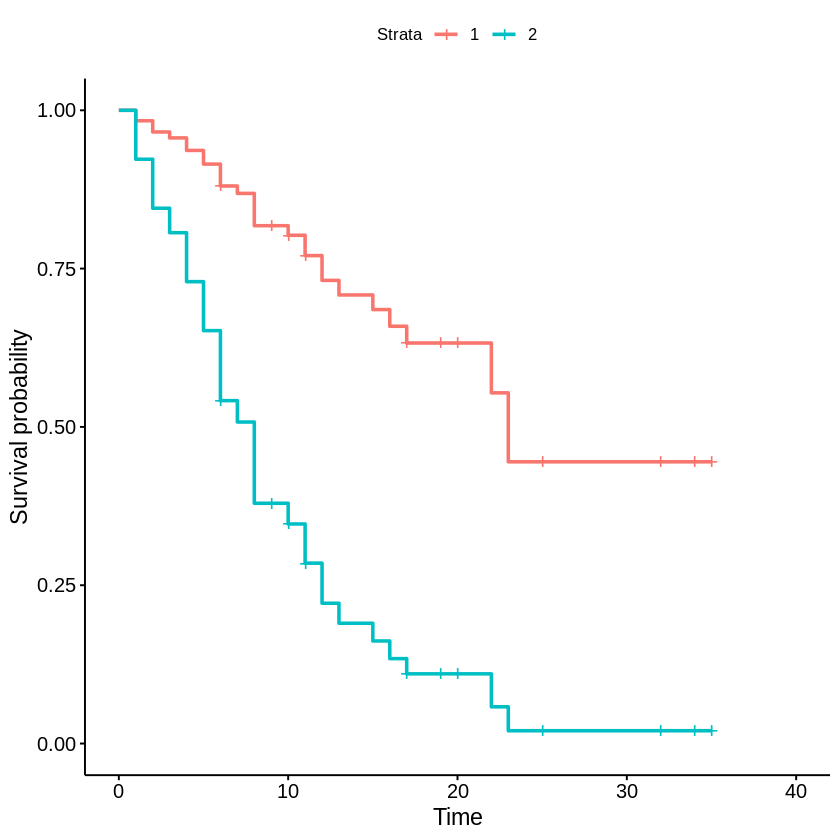

In [9]:
ggsurvplot(cox.survfit, data = leukemia, conf.int = FALSE)

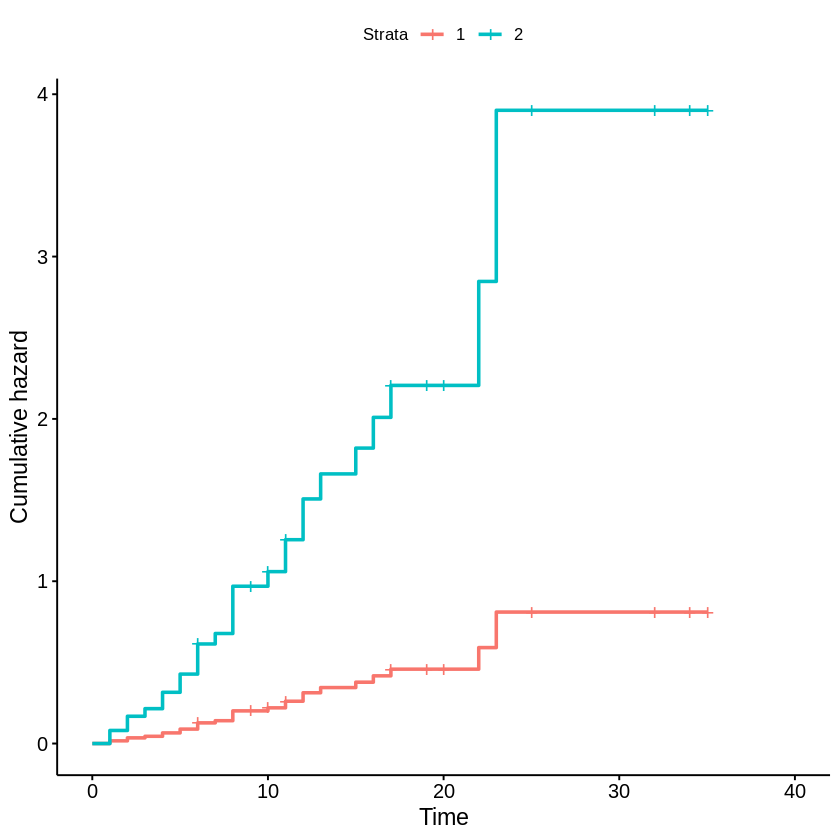

In [10]:
ggsurvplot(cox.survfit, data = leukemia, fun ='cumhaz', conf.int = FALSE)

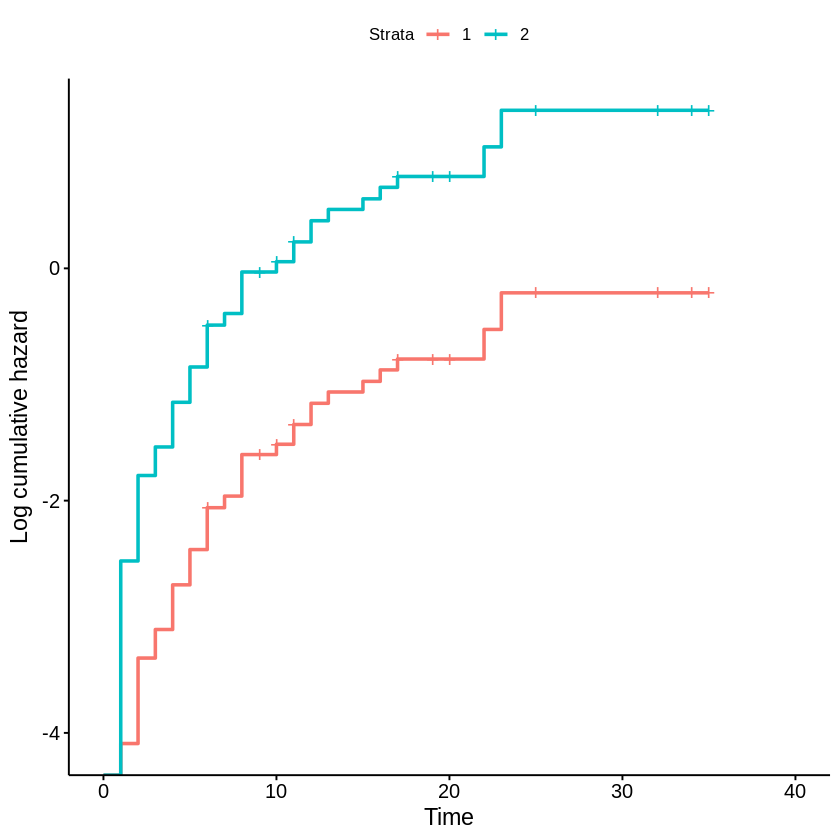

In [11]:
ggsurvplot(cox.survfit, data = leukemia, fun = \(s) log(-log(s)), conf.int = FALSE) +
  ylab('Log cumulative hazard')

# Multiple Cox PH model

* Of course, the motivation for the Cox PH model is to incorporate multiple and/or continuous covariates

* Here, we can fit a Cox PH model with Treatment group and logwbc count (log-base-2):

$$\lambda(t,\mathbf{X}) = \lambda_0(t) \exp(\beta_1 x_1 + \beta_2 x_2)$$

* $x_1 = 1$ for Group = 2, 0 for Group = 1
* $x_2$ is the log<sub>2</sub> white blood cell count

In [12]:
coxfit_wbc<- coxph(Surv(FUTime, Status) ~ factor(Group) + logwbc, data = leukemia)
summary(coxfit_wbc)

Call:
coxph(formula = Surv(FUTime, Status) ~ factor(Group) + logwbc, 
    data = leukemia)

  n= 42, number of events= 30 

                 coef exp(coef) se(coef)     z Pr(>|z|)    
factor(Group)2 1.3861    3.9991   0.4248 3.263   0.0011 ** 
logwbc         1.6909    5.4243   0.3359 5.034  4.8e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

               exp(coef) exp(-coef) lower .95 upper .95
factor(Group)2     3.999     0.2501     1.739     9.195
logwbc             5.424     0.1844     2.808    10.478

Concordance= 0.852  (se = 0.04 )
Likelihood ratio test= 46.71  on 2 df,   p=7e-11
Wald test            = 33.6  on 2 df,   p=5e-08
Score (logrank) test = 46.07  on 2 df,   p=1e-10


**Interpretations**

* Among people with the same WBC count, the hazard is 4 times higher for those in Group 2 than those in Group 1.  This is a statistically significant hazard ratio (p-value = 0.0011; 95% CI: 1.7, 9.2 does not overlap 1).

* Among people in the same treatment group, the hazard is 5.4 times greater for a 1-unit increase in log2(WBC).  This means the hazard is 5.4 times greater for each doubling in white blood cell count.  This hazard ratio is statistically significant (p-value < 0.0001; 95% CI: 2.8, 10.5).


## $\hat H$ and $\hat S$ for specific cohorts

* The `survfit` function can be used to return survival or hazard functions for specified values of the covariates.  

* E.g., the 25th percentile of logwbc was 2.3, and the 75th percentile was 3.5.

* Finding the fitted cumulative hazard and survival function for both groups individuals with these two `logwbc` values:


In [13]:
#The X values for which we want survival/hazard curves:
(cohort_data <- data.frame(Group = c(1,1,2,2), logwbc = c(2.3, 3.5, 2.3, 3.5)))

Group,logwbc
<dbl>,<dbl>
1,2.3
1,3.5
2,2.3
2,3.5


In [14]:
#Get the fitted survival object for this cohort:
group_wbc_combo_curves <- survfit(coxfit_wbc,  newdata = cohort_data)
summary(group_wbc_combo_curves)

Call: survfit(formula = coxfit_wbc, newdata = cohort_data)

 time n.risk n.event survival1 survival2 survival3 survival4
    1     42       2     0.998   0.98856    0.9940  9.55e-01
    2     40       2     0.996   0.97192    0.9851  8.92e-01
    3     38       1     0.994   0.95845    0.9779  8.44e-01
    4     37       2     0.990   0.92563    0.9602  7.34e-01
    5     35       2     0.984   0.88154    0.9359  6.04e-01
    6     33       3     0.971   0.79891    0.8887  4.07e-01
    7     29       1     0.966   0.77052    0.8719  3.53e-01
    8     28       4     0.940   0.62436    0.7806  1.52e-01
   10     23       1     0.931   0.57913    0.7504  1.13e-01
   11     21       2     0.910   0.48637    0.6846  5.60e-02
   12     18       2     0.878   0.37327    0.5957  1.94e-02
   13     16       1     0.860   0.31653    0.5462  1.00e-02
   15     15       1     0.840   0.26570    0.4982  4.99e-03
   16     14       1     0.819   0.21912    0.4502  2.31e-03
   17     13       1     

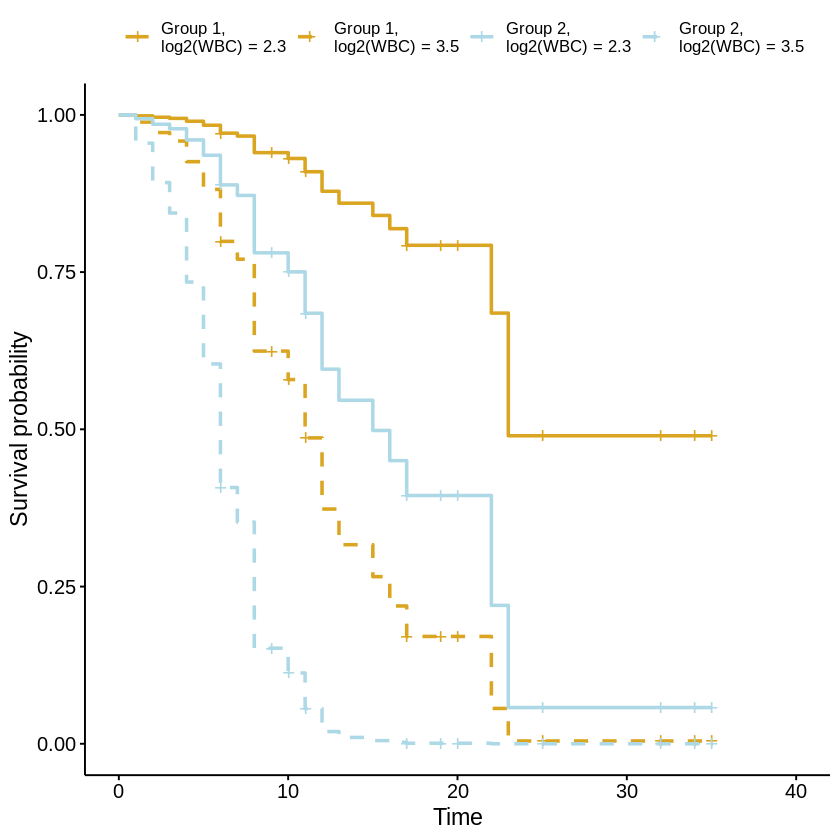

In [15]:
ggsurvplot(group_wbc_combo_curves,data =cohort_data, conf.int = FALSE,
legend.labs = c('Group 1,
log2(WBC) = 2.3','Group 1,
log2(WBC) = 3.5','Group 2,
log2(WBC) = 2.3','Group 2,
log2(WBC) = 3.5'),
  palette = c('goldenrod','goldenrod','lightblue','lightblue'),
  legend.title="", linetype = c(1,2,1,2))

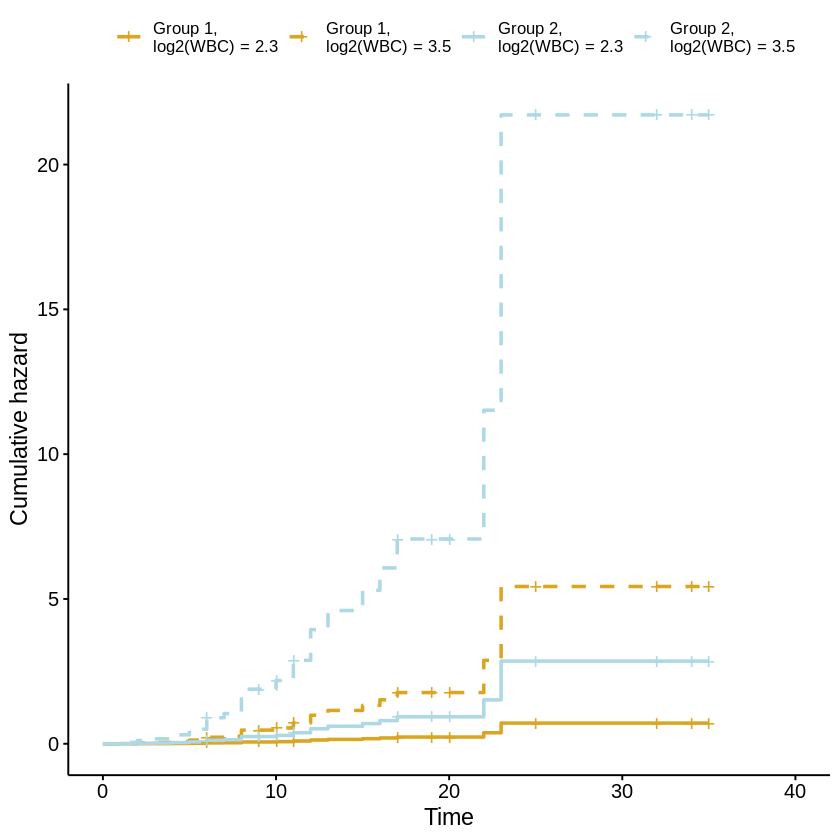

In [16]:
ggsurvplot(group_wbc_combo_curves,data =cohort_data, fun='cumhaz',conf.int = FALSE,
legend.labs = c('Group 1,
log2(WBC) = 2.3','Group 1,
log2(WBC) = 3.5','Group 2,
log2(WBC) = 2.3','Group 2,
log2(WBC) = 3.5'),
  linetype = c(1,2,1,2),
  palette = c('goldenrod','goldenrod','lightblue','lightblue'),
  legend.title="")

## Predicting at specific $t$

We can obtain predictions of $\hat H$ or $\hat S$ at a specific $(\mathbf{X},t)$ combination by putting these values in a data frame and using the `predict()` function:

*  `predict(coxmodel, newdata = prediction_covariates, type = 'expected')` returns $\hat H(t,\mathbf{X})$ estimates
*  `predict(coxmodel, newdata = prediction_covariates, type = 'survival')` returns $\hat S(t,\mathbf{X})$ estimates  

Suppose we want to provide the estimate 5- and 10-year hazard and survival probabilities for two individuals:
  - Group 1, logwbc = 2.3
  - Group 2, logwbc = 3.5

We put these covariates in a data frame; note that we also much include a "Status" column even though it's ultimately ignored in predicting (annoying!)


In [17]:
# look up chd survival calculator
(topredict <- data.frame(Group = c(1,2), logwbc = c(2.3, 3.5), FUTime = c(10,10, 20, 20), Status = NA))

Group,logwbc,FUTime,Status
<dbl>,<dbl>,<dbl>,<lgl>
1,2.3,10,NA
2,3.5,10,NA
1,2.3,20,NA
2,3.5,20,NA


In [18]:
#Predict H(X,t):
(hazard_predictions <- predict(coxfit_wbc, newdata = topredict, type ='expected'))

[1] 0.07180627 2.18444224 0.23240786 7.07015601

In [19]:
#Predict S(X,t):
(survival_predictions <- predict(coxfit_wbc, newdata = topredict, type ='survival'))

[1] 0.9307111842 0.1125404868 0.7926227813 0.0008501005

Adding these to the prediction data frame:

In [20]:
bind_cols(topredict, H =hazard_predictions, S=survival_predictions)

Group,logwbc,FUTime,Status,H,S
<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>
1,2.3,10,NA,0.07180627,0.9307111842
2,3.5,10,NA,2.18444224,0.1125404868
1,2.3,20,NA,0.23240786,0.7926227813
2,3.5,20,NA,7.07015601,0.0008501005


* Conditioning on $\mathbf{X}=\{Group, logwbc\}$, the 20-year survival estimates are smaller than the 10-year estimates, which makes sense.
* Conditioning on time, the survival probabilities are much lower for the Group = 2, logwbc = 3.5 than Group = 1, logwbc = 2.3.

## TASK

Fit a Cox PH model that includes gender, log WBC count, and group.  Use this model to predict the probability of surviving more than 15 years for someone with Gender = 1, logwbc = 3.0, and Group =2.


In [23]:
head(leukemia)

,Gender,Group,FUTime,Status,logwbc
,<int>,<int>,<int>,<int>,<dbl>
1,0,1,6,1,2.31
2,1,1,6,1,4.06
3,1,1,6,1,3.28
4,1,1,6,0,3.20
5,1,1,7,1,4.43
6,1,1,9,0,2.80


In [26]:
big_cox_model <- coxph(Surv(FUTime, Status) ~ factor(Gender) + logwbc + factor(Group), data = leukemia)

In [27]:
x_to_predict <- data.frame(Gender=1, logwbc=3, Group=2, FUTime=13, Status=NA)
x_to_predict

Gender,logwbc,Group,FUTime,Status
<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,3,2,13,NA


In [29]:
# The probability of survival is 12.2%
predict(big_cox_model, x_to_predict, type='survival')

[1] 0.1220455